# Extending the Diversity Vector: Discourse, Style, Narrative & Pragmatic Dimensions

**Prototyp v2** — Erweiterung des Credal-Set-Frameworks (Garces Arias et al., 2025)  
Daten: [`human_drift`](https://github.com/EstebanGarces/human_drift)

- **Storytelling (EN):** 100 Prompts × 10 Stories × 5 Sources
- **Translation (EN→DE):** 100 Prompts × 10 Übersetzungen × 5 Sources

### Upgrades gegenüber v1

| Komponente | v1 | v2 |
|---|---|---|
| $D_{\text{sem}}$ | TF-IDF Cosine | **SBERT** (`all-MiniLM-L6-v2`) |
| $D_{\text{syn}}$ | Regex-POS (8 Tags) | **spaCy** (`en_core_web_sm` / `de_core_news_sm`) |
| $D_{\text{disc}}$ Entity-Extraktion | Stopword-Filter | **spaCy NER** (EN) / Content-Words (DE) |
| Tasks | Storytelling only | **Storytelling + Translation** (Cross-Task-Drift) |

In [1]:
# Importieren der benötigten Bibliotheken
import numpy as np
import json, re, os, time, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from itertools import combinations
from collections import Counter, defaultdict
from scipy.spatial.distance import cdist
from scipy.spatial import ConvexHull
from scipy.stats import entropy, pearsonr, mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from matplotlib.patches import Polygon
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import spacy
from sentence_transformers import SentenceTransformer, util

warnings.filterwarnings('ignore')
np.random.seed(42)

# Konfiguration
N_PROMPTS = 100
SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
TASKS = ['storytelling', 'translations']
REPO_DIR = Path('human_drift')

SOURCE_COLORS = {
    'human':   '#1565C0',
    'llama':   '#E65100',
    'mistral': '#6A1B9A',
    'qwen':    '#2E7D32',
    'gemma':   '#C62828',
}

print('Alle Imports erfolgreich.')

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/Masterthesis/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Alle Imports erfolgreich.


In [4]:
! pip install spacy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
# ============================================================
# MODELLE LADEN
# ============================================================
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
nlp_en = spacy.load('en_core_web_sm')
nlp_de = spacy.load('de_core_news_sm')
print('SBERT, spaCy EN und spaCy DE Modelle geladen.')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10979.57it/s]


SBERT, spaCy EN und spaCy DE Modelle geladen.


In [6]:
# ============================================================
# ZUSÄTZLICHE BIBLIOTHEKEN INSTALLIEREN (falls nötig)
# ============================================================
!pip install -q sentence-transformers spacy
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 23.0 MB/s  0:00:00eta 0:00:01

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 23.4 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')


## 1. Daten laden (Storytelling + Translation)

In [8]:
# ============================================================
# 1. DATEN LADEN (Storytelling EN + Translation DE)
# ============================================================

if not REPO_DIR.exists():
    print('Klone human_drift Repo...')
    os.system(f'git clone --depth 1 https://github.com/EstebanGarces/human_drift.git {REPO_DIR}')

# texts[task][source][prompt_idx] = [text_1, ..., text_n]
texts = {task: {} for task in TASKS}

for source in SOURCES:
    # --- STORYTELLING: raw[prompt_str] = [story_1, ..., story_n] ---
    fp_story = REPO_DIR / 'clean_generations' / f'{source}_storytelling_clean.json'
    with open(fp_story) as f:
        raw_story = json.load(f)
    prompts_story = list(raw_story.keys())[:N_PROMPTS]
    texts['storytelling'][source] = {
        i: raw_story[p] for i, p in enumerate(prompts_story)
    }
    
    # --- TRANSLATION: raw[prompt_str] = {id: ..., human_translations: [...]} ---
    fp_trans = REPO_DIR / 'clean_generations' / f'{source}_translations_clean.json'
    with open(fp_trans) as f:
        raw_trans = json.load(f)
    prompts_trans = list(raw_trans.keys())[:N_PROMPTS]
    texts['translations'][source] = {
        i: raw_trans[p]['human_translations']
        for i, p in enumerate(prompts_trans)
    }

# Vorberechnete 3D-Metriken
with open(REPO_DIR / 'drift_analysis' / 'per_input_distances.json') as f:
    per_input_3d = json.load(f)

# Statistiken
for task in TASKS:
    lang = 'EN' if task == 'storytelling' else 'DE'
    total = sum(len(texts[task][s][p]) for s in SOURCES for p in texts[task][s])
    print(f'\n{task.upper()} ({lang}): {total:,} Texte')
    for source in SOURCES:
        all_texts = [t for p in range(N_PROMPTS) for t in texts[task][source][p]]
        lengths = [len(t) for t in all_texts]
        print(f'  {source:8s}: n={len(lengths)}, mean={np.mean(lengths):.0f} chars')
    # Sanity check
    sample = texts[task]['human'][0]
    print(f'  → Prompt 0 Unique: {len(set(sample))}/{len(sample)}')


STORYTELLING (EN): 4,994 Texte
  human   : n=1000, mean=2945 chars
  llama   : n=1000, mean=2567 chars
  mistral : n=1000, mean=2801 chars
  qwen    : n=994, mean=2107 chars
  gemma   : n=1000, mean=1798 chars
  → Prompt 0 Unique: 10/10

TRANSLATIONS (DE): 4,979 Texte
  human   : n=1000, mean=141 chars
  llama   : n=1000, mean=142 chars
  mistral : n=1000, mean=148 chars
  qwen    : n=979, mean=144 chars
  gemma   : n=1000, mean=139 chars
  → Prompt 0 Unique: 6/10


## 2. Bestehende Metriken (Baseline aus Paper)

In [9]:
# ============================================================
# 2. BASELINE-METRIKEN (sem, lex, syn) — mit Sprachunterstützung
# ============================================================

def semantic_distance_sbert(texts_list):
    """Semantic distance using SBERT embeddings."""
    if len(texts_list) < 2: return 0.0
    embeddings = sbert_model.encode(texts_list, convert_to_tensor=True)
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.mean([1 - util.pytorch_cos_sim(embeddings[i], embeddings[j]).item() for i, j in pairs])


def lexical_distance(texts_list):
    """Jaccard-Distanz auf Wort-Bigrammen."""
    if len(texts_list) < 2: return 0.0
    def bigrams(t):
        words = t.lower().split()
        return set(zip(words[:-1], words[1:]))
    bgs = [bigrams(t) for t in texts_list]
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.mean([1 - len(bgs[i] & bgs[j]) / max(len(bgs[i] | bgs[j]), 1)
                    for i, j in pairs])


def syntactic_distance_spacy(texts_list, lang='en'):
    """Jaccard auf POS-Trigrammen mit spaCy."""
    if len(texts_list) < 2: return 0.0
    nlp = nlp_en if lang == 'en' else nlp_de
    def pos_trigrams(t):
        doc = nlp(t)
        tags = [token.pos_ for token in doc]
        return set(zip(tags[:-2], tags[1:-1], tags[2:])) if len(tags) >= 3 else set()
    ps = [pos_trigrams(t) for t in texts_list]
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.mean([1 - len(ps[i] & ps[j]) / max(len(ps[i] | ps[j]), 1)
                    for i, j in pairs])


# Quick-Test
print('Storytelling (EN):')
test = texts['storytelling']['human'][0]
print(f'  D_sem={semantic_distance_sbert(test):.3f}, D_lex={lexical_distance(test):.3f}, '
      f'D_syn={syntactic_distance_spacy(test, "en"):.3f}')
print('Translation (DE):')
test_t = texts['translations']['human'][0]
print(f'  D_sem={semantic_distance_sbert(test_t):.3f}, D_lex={lexical_distance(test_t):.3f}, '
      f'D_syn={syntactic_distance_spacy(test_t, "de"):.3f}')

Storytelling (EN):
  D_sem=0.679, D_lex=0.986, D_syn=0.739
Translation (DE):
  D_sem=0.036, D_lex=0.353, D_syn=0.289


## 3. Neue Metrik: $D_{\text{disc}}$ — Discourse Diversity

In [10]:
# ============================================================
# 3. D_disc: DISCOURSE COHERENCE DIVERSITY (spaCy NER + DE Fallback)
# ============================================================

def sent_tokenize(text):
    sents = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sents if len(s.strip()) > 5]

def extract_entities_ner(sentence, lang='en'):
    """Extract named entities using spaCy NER."""
    nlp = nlp_en if lang == 'en' else nlp_de
    doc = nlp(sentence)
    valid_labels = {'PERSON', 'ORG', 'GPE', 'LOC', 'PRODUCT', 'EVENT', 'WORK_OF_ART',
                    'PER', 'MISC'}  # PER/MISC for German model
    return set(ent.text.lower() for ent in doc.ents if ent.label_ in valid_labels)

# German stopwords for content-word fallback
_STOPWORDS_DE = {'der', 'die', 'das', 'den', 'dem', 'des', 'ein', 'eine',
    'einem', 'einen', 'einer', 'und', 'oder', 'aber', 'in', 'an', 'auf',
    'aus', 'bei', 'für', 'mit', 'nach', 'von', 'zu', 'ist', 'sind',
    'war', 'hat', 'haben', 'wird', 'nicht', 'auch', 'sich', 'ich',
    'du', 'er', 'sie', 'es', 'wir', 'ihr', 'als', 'dass', 'so',
    'wie', 'wenn', 'noch', 'schon', 'nur', 'da', 'ob', 'doch',
    'über', 'unter', 'vor', 'zur', 'zum', 'im', 'am', 'vom',
    'wurde', 'werden', 'kann', 'müssen', 'soll', 'will', 'alle',
    'diese', 'dieser', 'mehr', 'sehr', 'nach', 'durch', 'zwischen',
    'gegen', 'ohne', 'bis', 'seit',
}

def entity_grid_transitions(text, lang='en'):
    sents = sent_tokenize(text)
    if len(sents) < 2:
        return Counter()
    
    if lang == 'en':
        sent_entities = [extract_entities_ner(s, lang='en') for s in sents]
    else:
        # German: NER + content-word fallback (short texts may have no NER hits)
        sent_entities_ner = [extract_entities_ner(s, lang='de') for s in sents]
        # Check if NER found anything
        all_ner = set().union(*sent_entities_ner)
        if len(all_ner) >= 3:
            sent_entities = sent_entities_ner
        else:
            # Fallback: content words (not stopwords, len > 3)
            sent_entities = [
                set(w for w in re.findall(r'\b[a-zäöüß]+\b', s.lower())
                    if w not in _STOPWORDS_DE and len(w) > 3)
                for s in sents
            ]
    
    all_entities = set().union(*sent_entities)
    if not all_entities:
        return Counter()
    transitions = Counter()
    for entity in all_entities:
        presence = [1 if entity in se else 0 for se in sent_entities]
        for j in range(len(presence) - 1):
            transitions[(presence[j], presence[j+1])] += 1
    return transitions

def jsd(p, q):
    p = np.asarray(p, dtype=float) + 1e-10
    q = np.asarray(q, dtype=float) + 1e-10
    p = p / p.sum(); q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (entropy(p, m) + entropy(q, m))

def discourse_diversity(texts_list, lang='en'):
    trans_types = [(0,0), (0,1), (1,0), (1,1)]
    profiles = []
    for t in texts_list:
        trans = entity_grid_transitions(t, lang=lang)
        total = sum(trans.values()) or 1
        profiles.append(np.array([trans[tt] / total for tt in trans_types]))
    profiles = np.array(profiles)
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.mean([jsd(profiles[i], profiles[j]) for i, j in pairs])

# Test
print(f'D_disc (EN/NER):     human story_0 = {discourse_diversity(texts["storytelling"]["human"][0], "en"):.4f}')
print(f'D_disc (DE/NER+CW):  human trans_0 = {discourse_diversity(texts["translations"]["human"][0], "de"):.4f}')

D_disc (EN/NER):     human story_0 = 0.0100
D_disc (DE/NER+CW):  human trans_0 = 0.0000


## 4. Neue Metrik: $D_{\text{style}}$ — Stylistic Diversity

In [11]:
# ============================================================
# 4. D_style: STYLISTIC DIVERSITY (sprachunabhängig)
# ============================================================

def style_profile(text):
    sents = sent_tokenize(text)
    words = re.findall(r'\b\w+\b', text)
    if not words or not sents:
        return np.zeros(7)
    sent_lengths = [len(re.findall(r'\b\w+\b', s)) for s in sents]
    words_lower = [w.lower() for w in words]
    return np.array([
        np.mean(sent_lengths),
        np.std(sent_lengths) if len(sent_lengths) > 1 else 0,
        len(set(words_lower)) / len(words_lower),
        sum(1 for w in words if len(w) > 6) / len(words),
        len(re.findall(r'[,;:\-\u2014]', text)) / len(words),
        sum(1 for s in sents if any(c in s for c in '\'\"\u2018\u201c')) / len(sents),
        sum(1 for s in sents if s.strip().endswith('?')) / len(sents),
    ])


def stylistic_diversity(texts_list):
    profiles = np.array([style_profile(t) for t in texts_list])
    means = profiles.mean(axis=0)
    stds = profiles.std(axis=0)
    stds[stds < 1e-10] = 1
    profiles_norm = (profiles - means) / stds
    pairs = list(combinations(range(len(texts_list)), 2))
    dists = [np.linalg.norm(profiles_norm[i] - profiles_norm[j]) for i, j in pairs]
    return 1 - np.exp(-np.mean(dists) / 2)


print(f'D_style: human story_0 = {stylistic_diversity(texts["storytelling"]["human"][0]):.4f}')
print(f'D_style: human trans_0 = {stylistic_diversity(texts["translations"]["human"][0]):.4f}')

D_style: human story_0 = 0.8490
D_style: human trans_0 = 0.5246


## 5. Neue Metrik: $D_{\text{narr}}$ — Narrative Diversity

In [12]:
# ============================================================
# 5. D_narr: NARRATIVE DIVERSITY (VADER sentiment arcs)
# NOTE: VADER ist Englisch-trainiert. Für deutsche Übersetzungen
#       basiert das Signal auf Kognaten, Zahlen und Interpunktion.
# ============================================================

analyzer = SentimentIntensityAnalyzer()

def sentiment_arc(text, n_points=10):
    sents = sent_tokenize(text)
    if len(sents) < 2:
        return np.zeros(n_points)
    scores = [analyzer.polarity_scores(s)['compound'] for s in sents]
    x_orig = np.linspace(0, 1, len(scores))
    x_interp = np.linspace(0, 1, n_points)
    return np.interp(x_interp, x_orig, scores)

def dtw_distance(arc1, arc2):
    n, m = len(arc1), len(arc2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(arc1[i-1] - arc2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m] / (n + m)

def narrative_diversity(texts_list):
    arcs = [sentiment_arc(t) for t in texts_list]
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.mean([dtw_distance(arcs[i], arcs[j]) for i, j in pairs])

print(f'D_narr: human story_0 = {narrative_diversity(texts["storytelling"]["human"][0]):.4f}')
print(f'D_narr: human trans_0 = {narrative_diversity(texts["translations"]["human"][0]):.4f}')

D_narr: human story_0 = 0.1455
D_narr: human trans_0 = 0.0000


## 6. Neue Metrik: $D_{\text{prag}}$ — Pragmatic Diversity

In [13]:
# ============================================================
# 6. D_prag: PRAGMATIC DIVERSITY (EN + DE)
# ============================================================

ACTION_WORDS = {'walked', 'ran', 'moved', 'grabbed', 'opened', 'closed', 'reached',
    'climbed', 'turned', 'pulled', 'pushed', 'stepped', 'stood', 'sat',
    'jumped', 'fell', 'hit', 'threw', 'caught', 'took', 'put', 'set',
    'dropped', 'picked', 'crept', 'approached', 'entered', 'left',
    'pressed', 'struck', 'rose', 'leaned', 'froze', 'lifted', 'placed',
    'pointed', 'kicked', 'slammed', 'swung', 'tossed', 'hurled',
    'charged', 'dashed', 'slid', 'bolted', 'lunged', 'clutched'}

REFLECTION_WORDS = {'thought', 'wondered', 'felt', 'knew', 'believed', 'realized',
    'remembered', 'imagined', 'wished', 'hoped', 'feared', 'noticed',
    'understood', 'considered', 'assumed', 'supposed', 'seemed',
    'mind', 'heart', 'soul', 'memory', 'dream', 'instinct'}

DESCRIPTION_WORDS = {'old', 'dark', 'cold', 'warm', 'bright', 'empty', 'silent',
    'loud', 'soft', 'hard', 'long', 'small', 'large', 'red',
    'green', 'blue', 'white', 'black', 'gray', 'golden',
    'beautiful', 'terrible', 'ancient', 'faint', 'thick', 'thin'}


def classify_sentence_en(sent):
    sent_lower = sent.lower()
    words = set(re.findall(r'\b\w+\b', sent_lower))
    if any(c in sent for c in ['\"', "\'", '\u201c', '\u2018']):
        if words & {'said', 'told', 'asked', 'whispered', 'yelled', 'called',
                    'replied', 'shouted', 'muttered', 'exclaimed', 'cried',
                    'answered', 'screamed'}:
            return 'dialog'
    if sent.strip().endswith('?'):
        return 'question'
    scores = {'action': len(words & ACTION_WORDS),
              'reflection': len(words & REFLECTION_WORDS),
              'description': len(words & DESCRIPTION_WORDS)}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'narration'


def classify_sentence_de(sent):
    """Satzfunktions-Klassifikation für deutsche Übersetzungen."""
    sent_lower = sent.lower()
    words = set(re.findall(r'\b\w+\b', sent_lower))
    # Direkte Rede
    if any(c in sent for c in ['\"', '\u201e', '\u201c', '\u201d']):
        if words & {'sagte', 'fragte', 'erklärte', 'meinte', 'antwortete',
                    'rief', 'flüsterte', 'schrie', 'bat'}:
            return 'dialog'
    if sent.strip().endswith('?'):
        return 'question'
    # Hedging / Unsicherheit
    if words & {'allerdings', 'möglicherweise', 'vielleicht', 'vermutlich',
                'offenbar', 'anscheinend', 'laut', 'zufolge'}:
        return 'hedge'
    # Zeitliche/räumliche Marker
    if words & {'gestern', 'heute', 'morgen', 'damals', 'kürzlich',
                'derzeit', 'zunächst', 'anschließend', 'schließlich'}:
        return 'temporal'
    # Zahlen/Statistik
    if re.search(r'\d+', sent) and words & {'prozent', 'millionen', 'milliarden',
                                             'euro', 'dollar', 'rund', 'etwa', 'circa'}:
        return 'factual'
    return 'neutral'


def pragmatic_profile(text, lang='en'):
    sents = sent_tokenize(text)
    if lang == 'en':
        cats = ['dialog', 'action', 'description', 'reflection', 'question', 'narration']
        classify_fn = classify_sentence_en
    else:
        cats = ['dialog', 'question', 'hedge', 'temporal', 'factual', 'neutral']
        classify_fn = classify_sentence_de
    if not sents:
        return np.ones(len(cats)) / len(cats)
    counts = Counter(classify_fn(s) for s in sents)
    total = sum(counts.values())
    return np.array([counts.get(c, 0) / total for c in cats])


def pragmatic_diversity(texts_list, lang='en'):
    profiles = [pragmatic_profile(t, lang=lang) for t in texts_list]
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.mean([np.sqrt(jsd(profiles[i], profiles[j])) for i, j in pairs])


print(f'D_prag: human story_0 = {pragmatic_diversity(texts["storytelling"]["human"][0], "en"):.4f}')
print(f'D_prag: human trans_0 = {pragmatic_diversity(texts["translations"]["human"][0], "de"):.4f}')

D_prag: human story_0 = 0.2556
D_prag: human trans_0 = 0.0000


## 7. Berechnung über alle Prompts, Sources und Tasks

In [14]:
# ============================================================
# 7. VOLLE BERECHNUNG (Storytelling EN + Translation DE)
# ============================================================

METRIC_NAMES = ['D_sem', 'D_lex', 'D_syn', 'D_disc', 'D_style', 'D_narr', 'D_prag']
METRIC_NAMES_SHORT = ['Sem', 'Lex', 'Syn', 'Disc', 'Style', 'Narr', 'Prag']

def get_metric_funcs(lang):
    return [
        semantic_distance_sbert,
        lexical_distance,
        lambda tl, la=lang: syntactic_distance_spacy(tl, lang=la),
        lambda tl, la=lang: discourse_diversity(tl, lang=la),
        stylistic_diversity,
        narrative_diversity,
        lambda tl, la=lang: pragmatic_diversity(tl, lang=la),
    ]

def compute_7d_vector(texts_list, funcs):
    return np.array([f(texts_list) for f in funcs])

# results[task][source] = array(N_PROMPTS, 7)
results = {task: {} for task in TASKS}

for task in TASKS:
    lang = 'en' if task == 'storytelling' else 'de'
    funcs = get_metric_funcs(lang)
    t0 = time.time()
    print(f'\n{"=" * 60}')
    print(f'  Computing {task.upper()} (lang={lang})...')
    print(f'{"=" * 60}')
    
    for source in SOURCES:
        vecs = []
        n_prompts = len(texts[task][source])
        for p in range(n_prompts):
            v = compute_7d_vector(texts[task][source][p], funcs)
            vecs.append(v)
            if (p + 1) % 25 == 0:
                elapsed = time.time() - t0
                print(f'  {source:8s}: {p+1}/{n_prompts} ({elapsed:.1f}s)')
        results[task][source] = np.array(vecs)
    
    elapsed = time.time() - t0
    print(f'  {task} fertig: {elapsed:.1f}s')


  Computing STORYTELLING (lang=en)...
  human   : 25/100 (49.2s)
  human   : 50/100 (97.7s)
  human   : 75/100 (143.4s)
  human   : 100/100 (187.3s)
  llama   : 25/100 (225.6s)
  llama   : 50/100 (264.4s)
  llama   : 75/100 (300.9s)
  llama   : 100/100 (340.7s)
  mistral : 25/100 (381.7s)
  mistral : 50/100 (420.4s)
  mistral : 75/100 (460.1s)
  mistral : 100/100 (498.4s)
  qwen    : 25/100 (529.8s)
  qwen    : 50/100 (560.5s)
  qwen    : 75/100 (590.9s)
  qwen    : 100/100 (622.3s)
  gemma   : 25/100 (651.0s)
  gemma   : 50/100 (678.5s)
  gemma   : 75/100 (707.4s)
  gemma   : 100/100 (735.9s)
  storytelling fertig: 735.9s

  Computing TRANSLATIONS (lang=de)...
  human   : 25/100 (3.6s)
  human   : 50/100 (6.5s)
  human   : 75/100 (9.3s)
  human   : 100/100 (11.7s)
  llama   : 25/100 (14.1s)
  llama   : 50/100 (16.6s)
  llama   : 75/100 (19.2s)
  llama   : 100/100 (21.4s)
  mistral : 25/100 (23.9s)
  mistral : 50/100 (26.8s)
  mistral : 75/100 (29.5s)
  mistral : 100/100 (31.9s)
  qwe

In [15]:
# ============================================================
# 7b. ERGEBNISTABELLE (beide Tasks)
# ============================================================

for task in TASKS:
    lang = 'EN' if task == 'storytelling' else 'DE'
    print(f'\n{"=" * 85}')
    print(f'  {task.upper()} ({lang}): Mean ± Std ({N_PROMPTS} Prompts)')
    print(f'{"=" * 85}')
    print(f'{"Metrik":<10}', end='')
    for source in SOURCES:
        print(f'{source:>15}', end='')
    print()
    print('-' * 85)
    
    for i, name in enumerate(METRIC_NAMES_SHORT):
        print(f'{name:<10}', end='')
        for source in SOURCES:
            m = results[task][source][:, i].mean()
            s = results[task][source][:, i].std()
            print(f'{m:>9.4f}±{s:<5.3f}', end='')
        print()

print()
print('Δ (Human - Modell) — STORYTELLING:')
print(f'{"Metrik":<10}', end='')
for source in SOURCES[1:]:
    print(f'{source:>14}', end='')
print()
print('-' * 66)
for i, name in enumerate(METRIC_NAMES_SHORT):
    print(f'{name:<10}', end='')
    h_mean = results['storytelling']['human'][:, i].mean()
    for source in SOURCES[1:]:
        delta = h_mean - results['storytelling'][source][:, i].mean()
        sign = '+' if delta > 0 else ''
        print(f'{sign}{delta:>13.4f}', end='')
    print()


  STORYTELLING (EN): Mean ± Std (100 Prompts)
Metrik              human          llama        mistral           qwen          gemma
-------------------------------------------------------------------------------------
Sem          0.6430±0.078   0.3413±0.095   0.3047±0.084   0.3517±0.078   0.3449±0.081
Lex          0.9850±0.004   0.9365±0.018   0.9363±0.020   0.9592±0.013   0.9582±0.012
Syn          0.7456±0.037   0.6276±0.033   0.6215±0.024   0.6588±0.037   0.6560±0.026
Disc         0.0627±0.043   0.0581±0.043   0.0519±0.041   0.0559±0.042   0.0665±0.050
Style        0.8471±0.007   0.8471±0.015   0.8400±0.012   0.8458±0.012   0.8471±0.010
Narr         0.1406±0.019   0.1369±0.026   0.1422±0.023   0.1296±0.020   0.1299±0.021
Prag         0.2866±0.041   0.2317±0.060   0.2138±0.035   0.2374±0.059   0.2361±0.045

  TRANSLATIONS (DE): Mean ± Std (100 Prompts)
Metrik              human          llama        mistral           qwen          gemma
----------------------------------------------

## 8. Visualisierungen

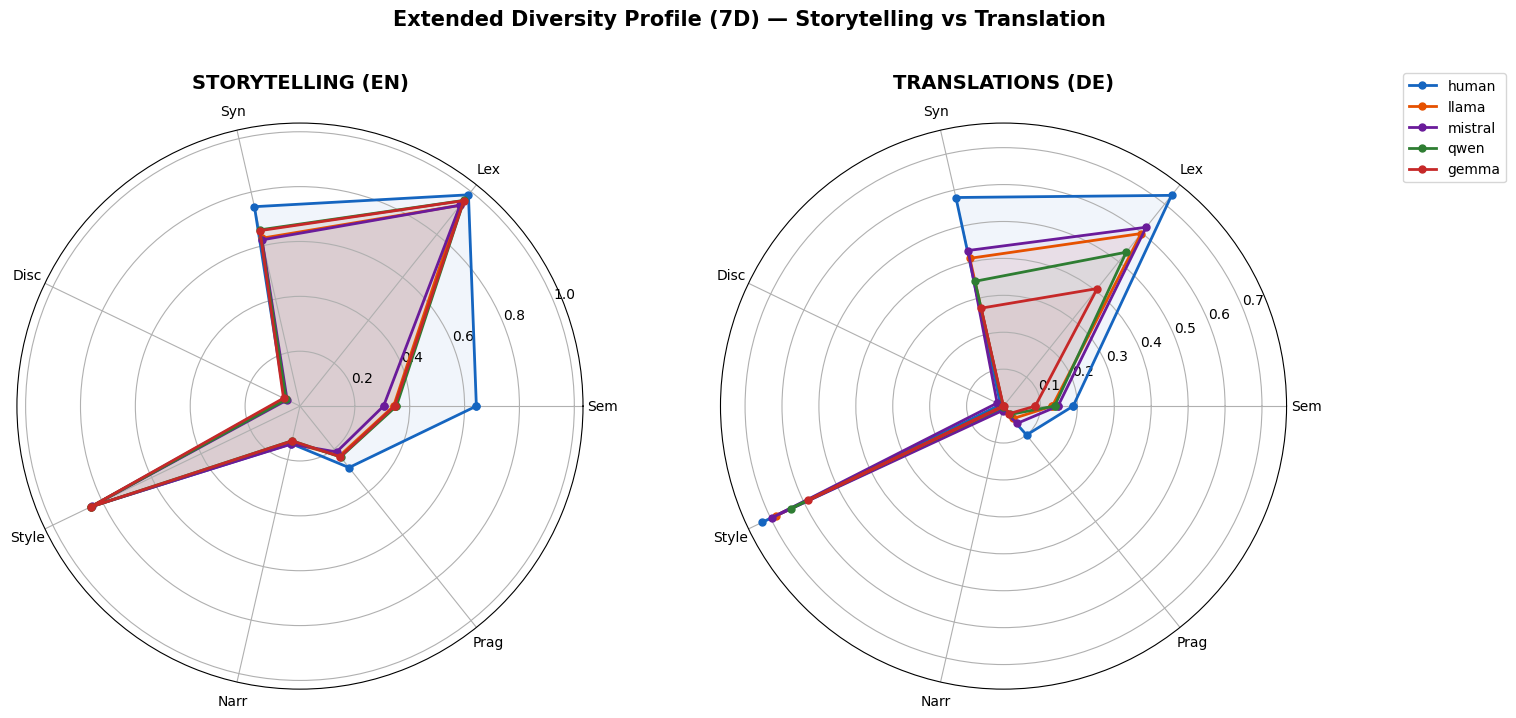

In [16]:
# ============================================================
# 8a. RADAR CHARTS: Storytelling vs Translation
# ============================================================

angles = np.linspace(0, 2 * np.pi, 7, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw=dict(polar=True))

for ax, task in zip(axes, TASKS):
    lang = 'EN' if task == 'storytelling' else 'DE'
    for source in SOURCES:
        means = results[task][source].mean(axis=0)
        values = means.tolist() + [means[0]]
        ax.plot(angles, values, 'o-', color=SOURCE_COLORS[source],
                linewidth=2, label=source, markersize=5)
        ax.fill(angles, values, alpha=0.06, color=SOURCE_COLORS[source])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(METRIC_NAMES_SHORT, fontsize=10)
    ax.set_title(f'{task.upper()} ({lang})', fontsize=14, fontweight='bold', pad=25)

axes[1].legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10)
fig.suptitle('Extended Diversity Profile (7D) — Storytelling vs Translation',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8b. Boxplot: Verteilungen pro Metrik und Source

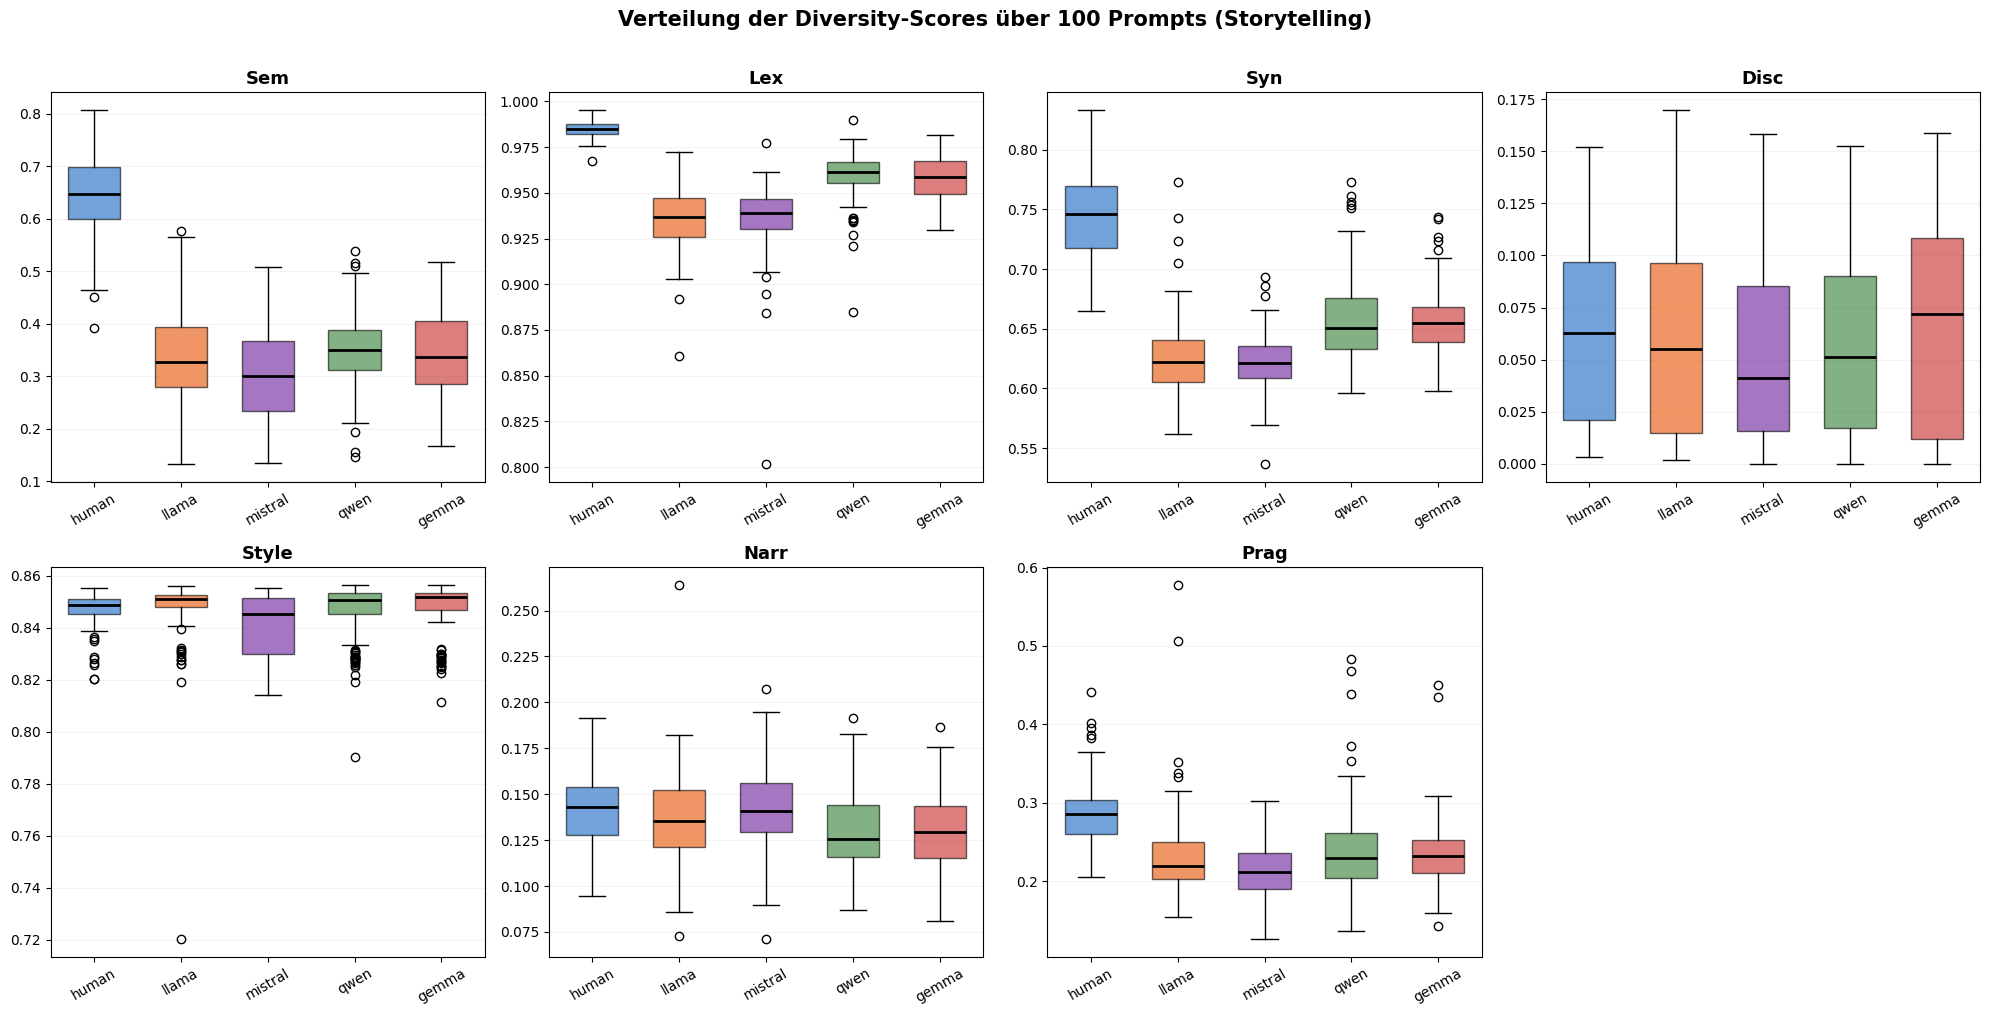

In [17]:
# ============================================================
# 8b. BOXPLOTS (Storytelling)
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for i, (name, ax) in enumerate(zip(METRIC_NAMES_SHORT, axes_flat[:7])):
    data = [results['storytelling'][s][:, i] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2), widths=0.6)
    for patch, source in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[source])
        patch.set_alpha(0.6)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')

axes_flat[7].set_visible(False)
fig.suptitle('Verteilung der Diversity-Scores über 100 Prompts (Storytelling)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

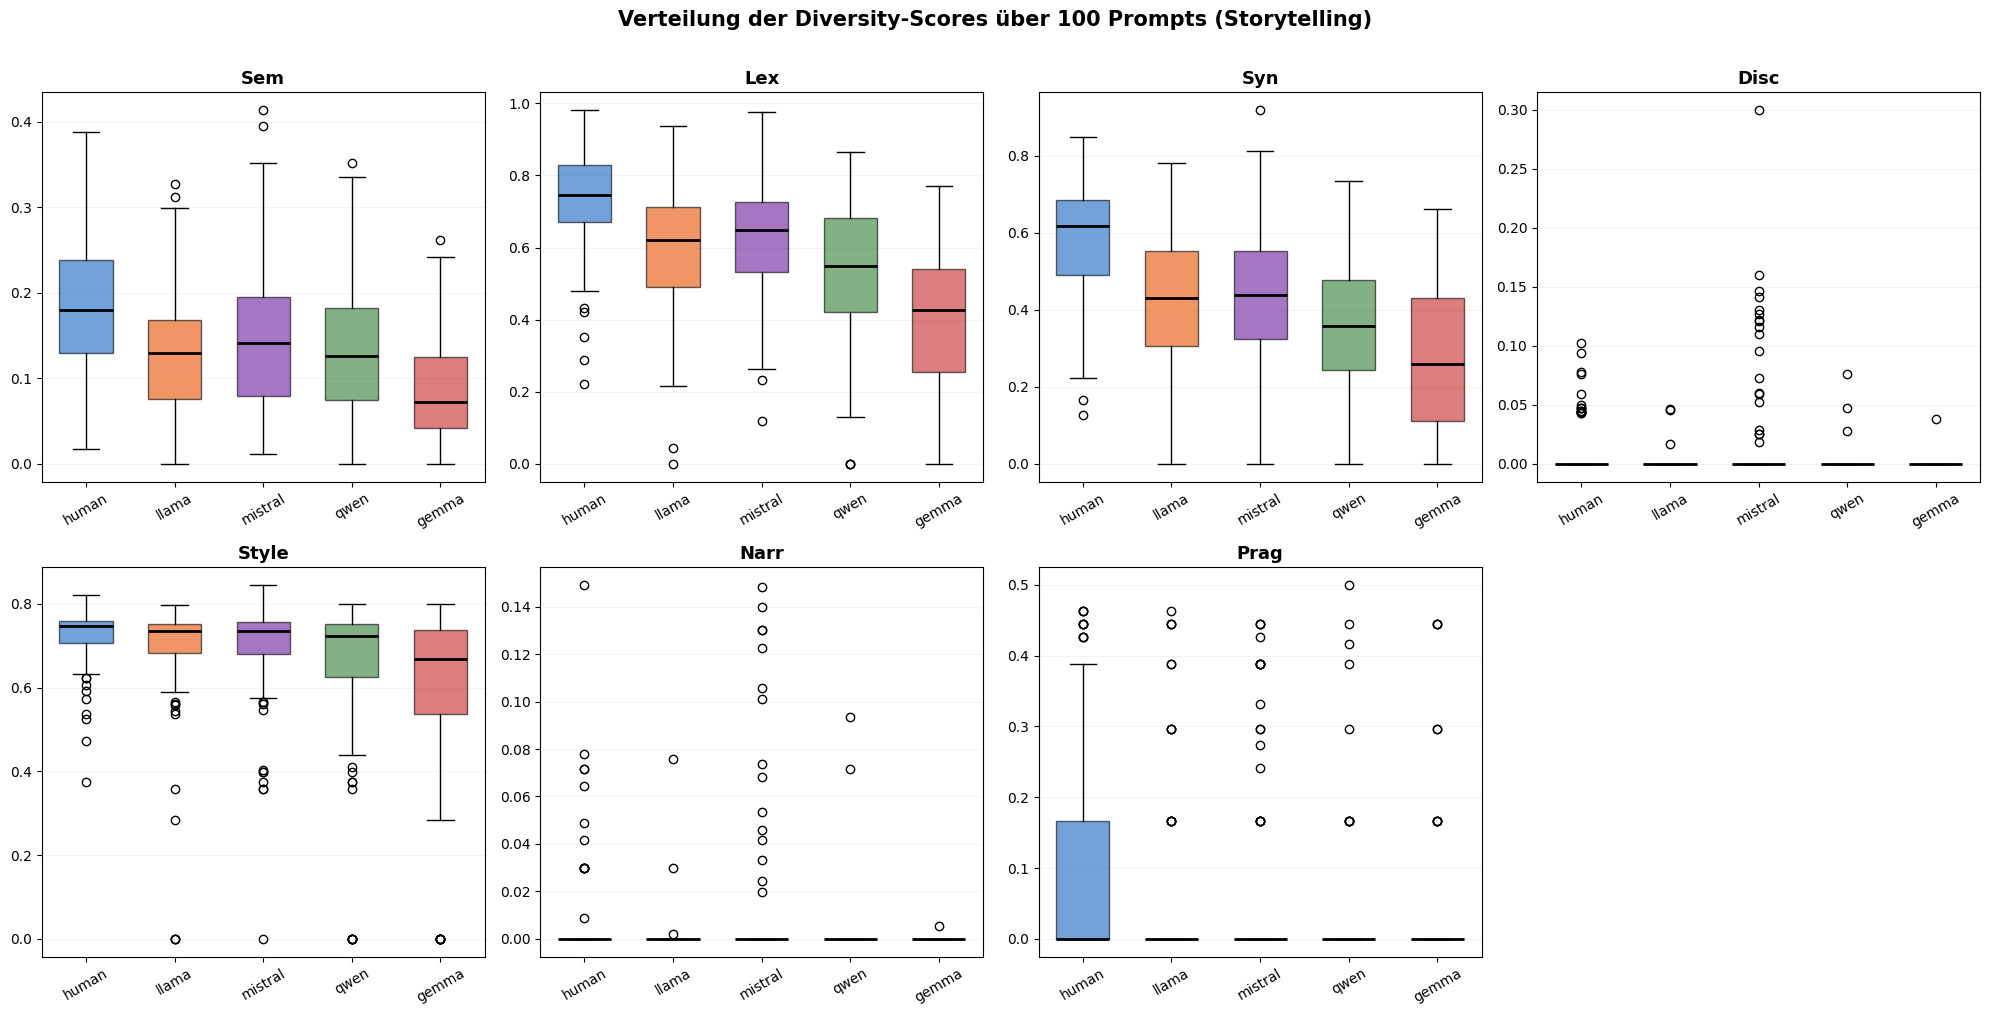

In [19]:
# ============================================================
# 8b. BOXPLOTS (Translation)
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for i, (name, ax) in enumerate(zip(METRIC_NAMES_SHORT, axes_flat[:7])):
    data = [results['translations'][s][:, i] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2), widths=0.6)
    for patch, source in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[source])
        patch.set_alpha(0.6)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')

axes_flat[7].set_visible(False)
fig.suptitle('Verteilung der Diversity-Scores über 100 Prompts (Storytelling)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 8c. Sentiment-Arc-Vergleich (Beispiel-Prompt)

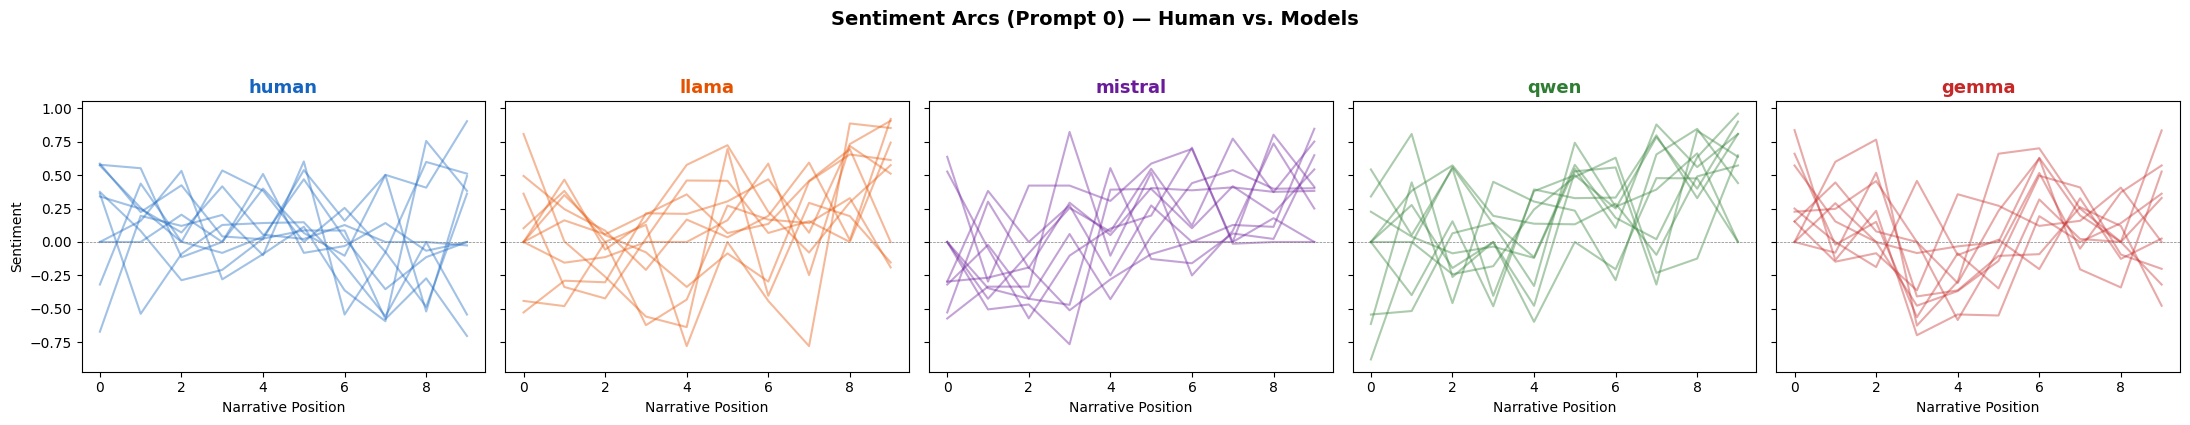

In [20]:
# ============================================================
# 8c. SENTIMENT ARCS (Prompt 0, Storytelling)
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
for ax, source in zip(axes, SOURCES):
    for story in texts['storytelling'][source][0]:
        arc = sentiment_arc(story)
        ax.plot(range(10), arc, alpha=0.4, color=SOURCE_COLORS[source], linewidth=1.5)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(source, fontsize=13, fontweight='bold', color=SOURCE_COLORS[source])
    ax.set_xlabel('Narrative Position')

axes[0].set_ylabel('Sentiment')
fig.suptitle('Sentiment Arcs (Prompt 0) — Human vs. Models',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 8d. Cross-Task Drift: Diversitätslücke

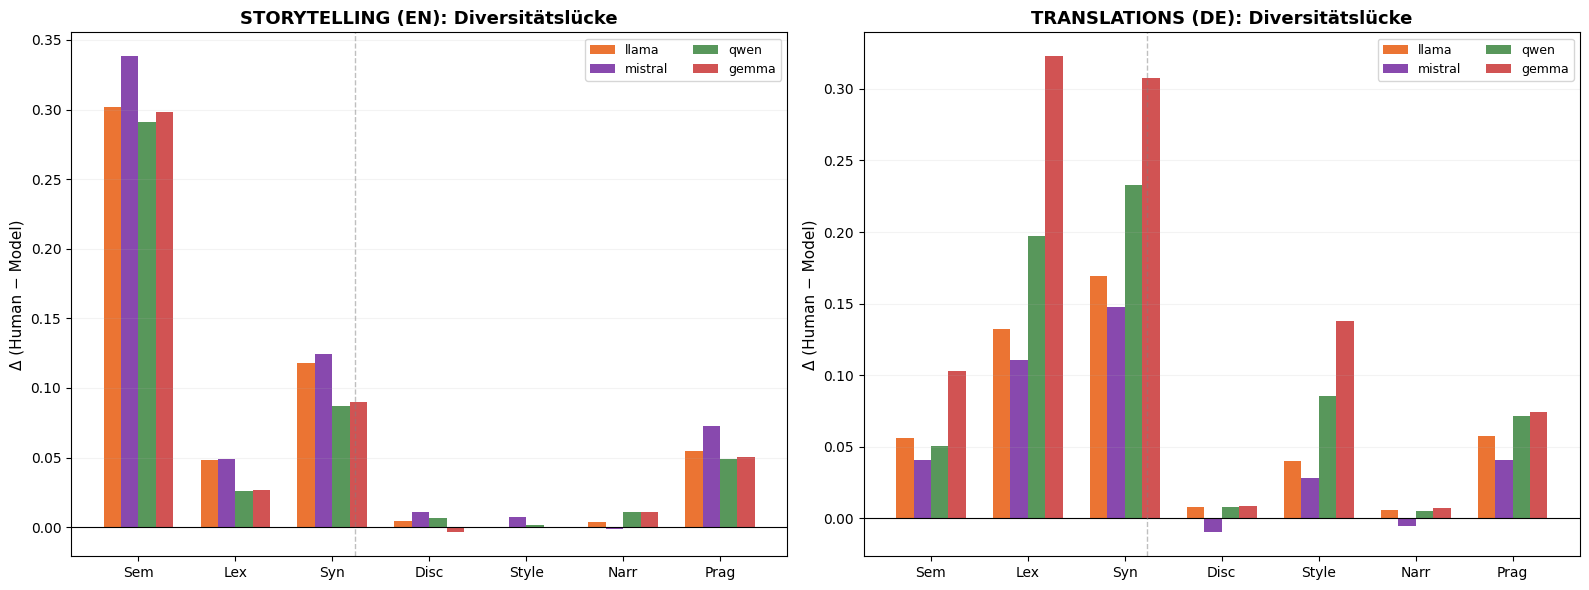

In [21]:
# ============================================================
# 8d. CROSS-TASK DRIFT: Diversitätslücke pro Dimension
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, task in zip(axes, TASKS):
    lang = 'EN' if task == 'storytelling' else 'DE'
    x = np.arange(7)
    width = 0.18
    for j, source in enumerate(SOURCES[1:]):
        deltas = results[task]['human'].mean(axis=0) - results[task][source].mean(axis=0)
        ax.bar(x + j*width, deltas, width, label=source,
               color=SOURCE_COLORS[source], alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(2.5, color='gray', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels(METRIC_NAMES_SHORT, fontsize=10)
    ax.set_ylabel('Δ (Human − Model)', fontsize=11)
    ax.set_title(f'{task.upper()} ({lang}): Diversitätslücke', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.show()

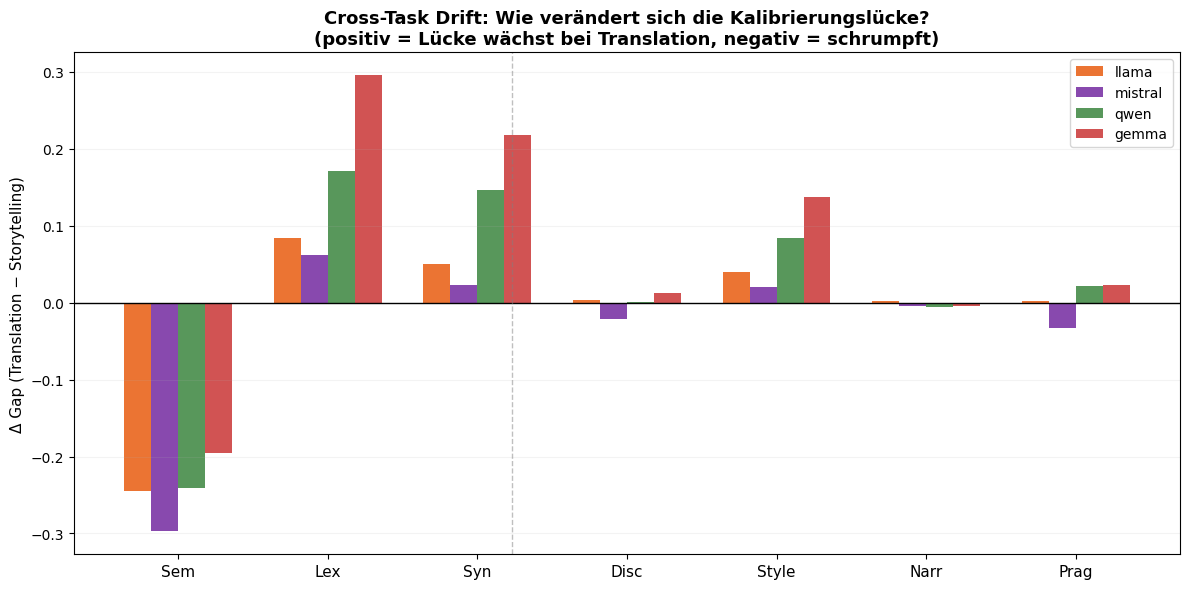

In [22]:
# ============================================================
# 8e. DRIFT DIRECTION: Story → Translation Lückenverschiebung
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(7)
width = 0.18
for j, source in enumerate(SOURCES[1:]):
    gap_story = results['storytelling']['human'].mean(0) - results['storytelling'][source].mean(0)
    gap_trans  = results['translations']['human'].mean(0) - results['translations'][source].mean(0)
    drift = gap_trans - gap_story
    ax.bar(x + j*width, drift, width, label=source,
           color=SOURCE_COLORS[source], alpha=0.8)

ax.axhline(0, color='black', linewidth=1)
ax.axvline(2.5, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(METRIC_NAMES_SHORT, fontsize=11)
ax.set_ylabel('Δ Gap (Translation − Storytelling)', fontsize=11)
ax.set_title('Cross-Task Drift: Wie verändert sich die Kalibrierungslücke?\n'
             '(positiv = Lücke wächst bei Translation, negativ = schrumpft)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.show()

## 9. Korrelationsanalyse: Sind die neuen Dimensionen orthogonal?

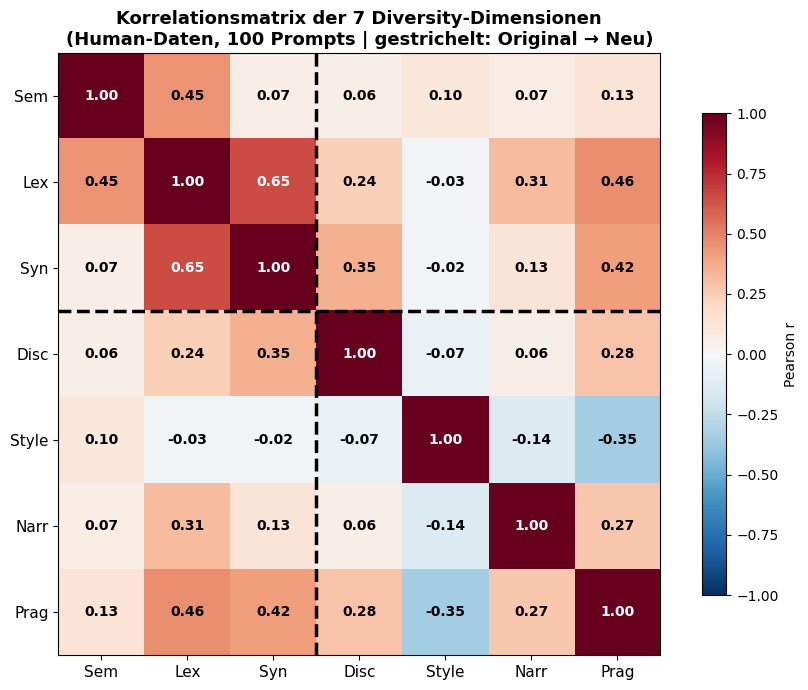


Korrelationen ORIGINAL ↔ NEU:
    Sem–Disc  : r=+0.058 (schwach)
    Sem–Style : r=+0.104 (schwach)
    Sem–Narr  : r=+0.071 (schwach)
    Sem–Prag  : r=+0.133 (schwach)
    Lex–Disc  : r=+0.241 (schwach)
    Lex–Style : r=-0.030 (schwach)
    Lex–Narr  : r=+0.313 (moderat)
    Lex–Prag  : r=+0.462 (moderat)
    Syn–Disc  : r=+0.353 (moderat)
    Syn–Style : r=-0.025 (schwach)
    Syn–Narr  : r=+0.129 (schwach)
    Syn–Prag  : r=+0.421 (moderat)


In [23]:
# ============================================================
# 9. KORRELATIONSANALYSE
# ============================================================

human_data = results['storytelling']['human']
corr_matrix = np.corrcoef(human_data.T)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(7)); ax.set_yticks(range(7))
ax.set_xticklabels(METRIC_NAMES_SHORT, fontsize=11)
ax.set_yticklabels(METRIC_NAMES_SHORT, fontsize=11)

for i in range(7):
    for j in range(7):
        color = 'white' if abs(corr_matrix[i, j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=10, color=color, fontweight='bold')

ax.axhline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.axvline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.set_title('Korrelationsmatrix der 7 Diversity-Dimensionen\n'
             '(Human-Daten, 100 Prompts | gestrichelt: Original → Neu)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.show()

print('\nKorrelationen ORIGINAL ↔ NEU:')
for i in range(3):
    for j in range(3, 7):
        r = corr_matrix[i, j]
        strength = 'stark' if abs(r) > 0.5 else 'moderat' if abs(r) > 0.3 else 'schwach'
        print(f'  {METRIC_NAMES_SHORT[i]:>5}–{METRIC_NAMES_SHORT[j]:<6}: r={r:+.3f} ({strength})')

## 10. PCA-Analyse: 3D vs 7D

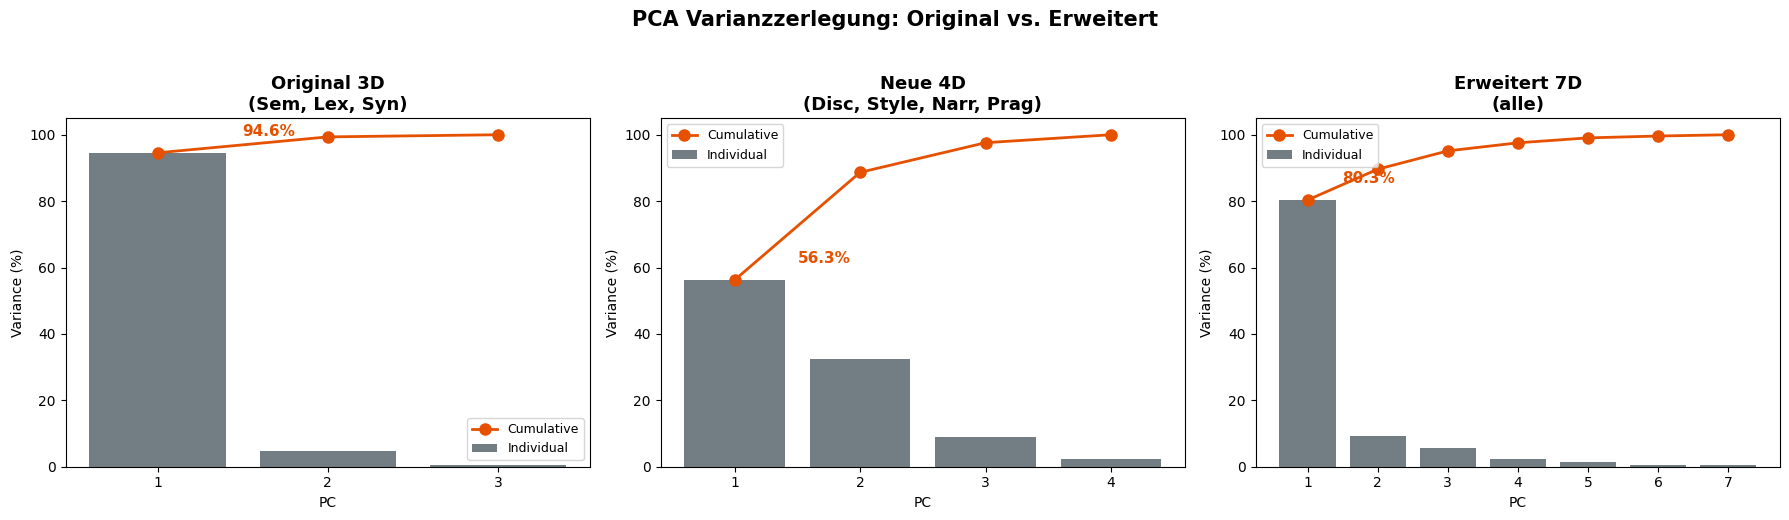

PC1: 3D=94.6%, 4D=56.3%, 7D=80.3%
Paper (3D): 85.8%


In [24]:
# ============================================================
# 10. PCA: 3D vs 7D
# ============================================================

all_7d = np.vstack([results['storytelling'][s] for s in SOURCES])
all_3d = all_7d[:, :3]
all_4d = all_7d[:, 3:]

pca_3d = PCA().fit(all_3d)
pca_7d = PCA().fit(all_7d)
pca_4d = PCA().fit(all_4d)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pca_obj, title, n_dim in [
    (axes[0], pca_3d, 'Original 3D\n(Sem, Lex, Syn)', 3),
    (axes[1], pca_4d, 'Neue 4D\n(Disc, Style, Narr, Prag)', 4),
    (axes[2], pca_7d, 'Erweitert 7D\n(alle)', 7),
]:
    var = pca_obj.explained_variance_ratio_ * 100
    cum = np.cumsum(var)
    ax.bar(range(1, n_dim+1), var, color='#37474F', alpha=0.7, label='Individual')
    ax.plot(range(1, n_dim+1), cum, 'o-', color='#E65100', linewidth=2,
            markersize=8, label='Cumulative')
    ax.set_xlabel('PC'); ax.set_ylabel('Variance (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(range(1, n_dim+1))
    ax.legend(fontsize=9)
    ax.annotate(f'{var[0]:.1f}%', xy=(1, var[0]), xytext=(1.5, var[0]+5),
                fontsize=11, fontweight='bold', color='#E65100')

plt.suptitle('PCA Varianzzerlegung: Original vs. Erweitert',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f'PC1: 3D={pca_3d.explained_variance_ratio_[0]:.1%}, '
      f'4D={pca_4d.explained_variance_ratio_[0]:.1%}, '
      f'7D={pca_7d.explained_variance_ratio_[0]:.1%}')
print(f'Paper (3D): 85.8%')

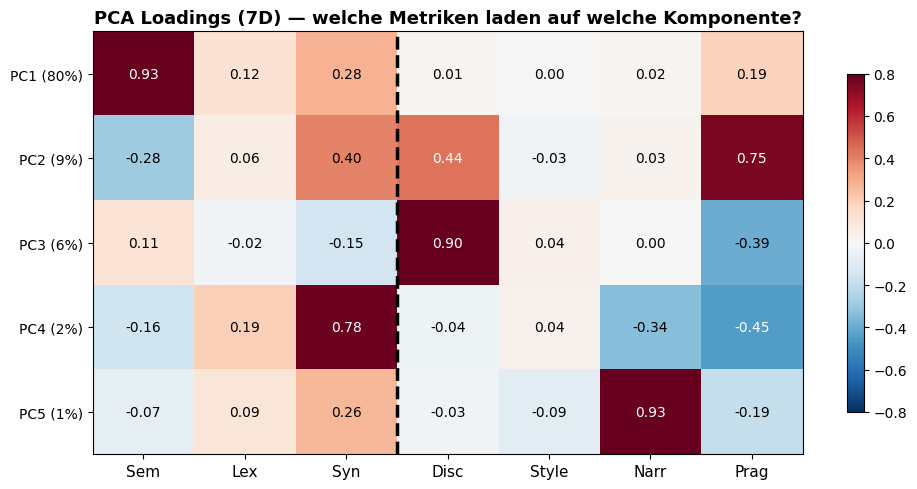

In [25]:
# ============================================================
# 10b. PCA LOADINGS HEATMAP
# ============================================================

n_pcs = min(5, len(pca_7d.components_))
loadings = pca_7d.components_[:n_pcs]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(loadings, cmap='RdBu_r', vmin=-0.8, vmax=0.8, aspect='auto')
ax.set_xticks(range(7))
ax.set_xticklabels(METRIC_NAMES_SHORT, fontsize=11)
ax.set_yticks(range(n_pcs))
ax.set_yticklabels([f'PC{i+1} ({pca_7d.explained_variance_ratio_[i]:.0%})'
                     for i in range(n_pcs)], fontsize=10)
for i in range(n_pcs):
    for j in range(7):
        c = 'white' if abs(loadings[i,j]) > 0.4 else 'black'
        ax.text(j, i, f'{loadings[i,j]:.2f}', ha='center', va='center',
                fontsize=10, color=c)

ax.axvline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.set_title('PCA Loadings (7D) — welche Metriken laden auf welche Komponente?',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 11. Credal Sets im erweiterten Raum

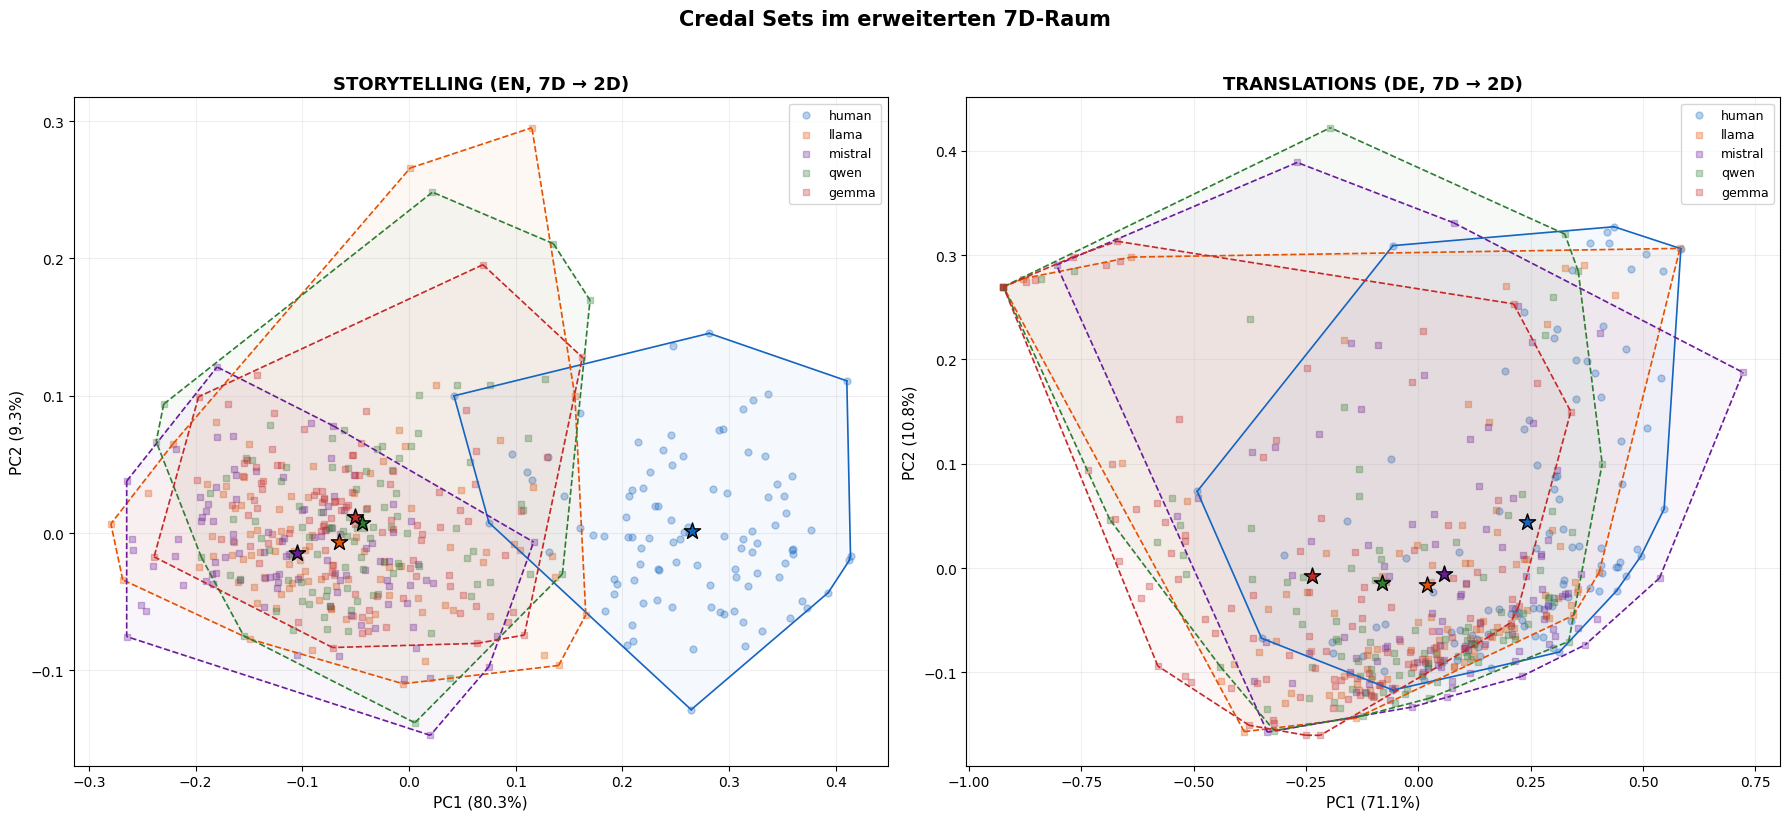

In [26]:
# ============================================================
# 11. CREDAL SETS (Side-by-side: Storytelling vs Translation)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, task in zip(axes, TASKS):
    lang = 'EN' if task == 'storytelling' else 'DE'
    all_data = np.vstack([results[task][s] for s in SOURCES])
    pca_2d = PCA(n_components=2)
    all_pca = pca_2d.fit_transform(all_data)
    
    for i, source in enumerate(SOURCES):
        n = len(results[task][source])
        pts = all_pca[i*n:(i+1)*n]
        marker = 'o' if source == 'human' else 's'
        ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source], alpha=0.3,
                  s=25, marker=marker, label=source)
        centroid = pts.mean(axis=0)
        ax.scatter(*centroid, c=SOURCE_COLORS[source], s=150, marker='*',
                  edgecolors='black', linewidth=1, zorder=5)
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ls = '-' if source == 'human' else '--'
                ax.plot(pts[simplex, 0], pts[simplex, 1],
                        color=SOURCE_COLORS[source], linewidth=1.2, linestyle=ls)
            poly = Polygon(pts[hull.vertices], alpha=0.04, color=SOURCE_COLORS[source])
            ax.add_patch(poly)
        except Exception:
            pass
    
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax.set_title(f'{task.upper()} ({lang}, 7D → 2D)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('Credal Sets im erweiterten 7D-Raum',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 11b. OVERLAP-KOEFFIZIENT (beide Tasks)
# ============================================================

def overlap_coefficient(points_a, points_b):
    dists_ab = cdist(points_a, points_b)
    dists_ba = cdist(points_b, points_a)
    all_pts = np.vstack([points_a, points_b])
    all_d = cdist(all_pts, all_pts)
    np.fill_diagonal(all_d, np.inf)
    theta = 0.5 * np.mean(all_d.min(axis=1))
    a_near = np.mean(dists_ab.min(axis=1) < theta)
    b_near = np.mean(dists_ba.min(axis=1) < theta)
    return 0.5 * (a_near + b_near)

print('=' * 85)
print('KALIBRIERUNG: Overlap Human ↔ Modell (3D vs 7D, beide Tasks)')
print('=' * 85)

for task in TASKS:
    lang = 'EN' if task == 'storytelling' else 'DE'
    h = results[task]['human']
    print(f'\n  {task.upper()} ({lang})')
    print(f'  {"Modell":<10} {"3D (orig)":>10} {"4D (neu)":>10} {"7D (alle)":>10} {"Δ(3D→7D)":>10}')
    print(f'  {"-"*55}')
    
    for source in SOURCES[1:]:
        m = results[task][source]
        ov_3d = overlap_coefficient(h[:, :3], m[:, :3])
        ov_4d = overlap_coefficient(h[:, 3:], m[:, 3:])
        ov_7d = overlap_coefficient(h, m)
        delta = ov_7d - ov_3d
        print(f'  {source:<10} {ov_3d:>10.3f} {ov_4d:>10.3f} {ov_7d:>10.3f} {delta:>+10.3f}')

KALIBRIERUNG: Overlap Human ↔ Modell (3D vs 7D, beide Tasks)

  STORYTELLING (EN)
  Modell      3D (orig)   4D (neu)  7D (alle)   Δ(3D→7D)
  -------------------------------------------------------
  llama           0.000      0.090      0.000     +0.000
  mistral         0.000      0.055      0.000     +0.000
  qwen            0.000      0.035      0.000     +0.000
  gemma           0.000      0.020      0.000     +0.000

  TRANSLATIONS (DE)
  Modell      3D (orig)   4D (neu)  7D (alle)   Δ(3D→7D)
  -------------------------------------------------------
  llama           0.085      0.645      0.070     -0.015
  mistral         0.110      0.595      0.075     -0.035
  qwen            0.040      0.640      0.050     +0.010
  gemma           0.040      0.555      0.060     +0.020


## 12. Statistische Signifikanz (Mann-Whitney U)

In [28]:
# ============================================================
# 12. MANN-WHITNEY U: Human vs Model pro Dimension
# ============================================================

print('Mann-Whitney U Tests: Human vs. Modell pro Dimension')
print('(p < 0.05 = signifikanter Unterschied)\n')

for task in TASKS:
    lang = 'EN' if task == 'storytelling' else 'DE'
    print(f'{task.upper()} ({lang})')
    print(f'{"Metrik":<8}', end='')
    for source in SOURCES[1:]:
        print(f'{source:>18}', end='')
    print()
    print('-' * 80)
    
    h = results[task]['human']
    for i, name in enumerate(METRIC_NAMES_SHORT):
        print(f'{name:<8}', end='')
        for source in SOURCES[1:]:
            m = results[task][source]
            stat, p = mannwhitneyu(h[:, i], m[:, i], alternative='two-sided')
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
            effect = abs(h[:, i].mean() - m[:, i].mean()) / max(h[:, i].std(), 0.001)
            print(f'{sig:>6} (d={effect:.2f})', end='')
        print()
    print()

Mann-Whitney U Tests: Human vs. Modell pro Dimension
(p < 0.05 = signifikanter Unterschied)

STORYTELLING (EN)
Metrik               llama           mistral              qwen             gemma
--------------------------------------------------------------------------------
Sem        *** (d=3.85)   *** (d=4.32)   *** (d=3.72)   *** (d=3.80)
Lex        *** (d=11.72)   *** (d=11.76)   *** (d=6.25)   *** (d=6.48)
Syn        *** (d=3.16)   *** (d=3.32)   *** (d=2.32)   *** (d=2.40)
Disc      n.s. (d=0.11)  n.s. (d=0.25)  n.s. (d=0.16)  n.s. (d=0.09)
Style       ** (d=0.00)    ** (d=0.99)  n.s. (d=0.19)    ** (d=0.00)
Narr      n.s. (d=0.20)  n.s. (d=0.08)   *** (d=0.58)   *** (d=0.57)
Prag       *** (d=1.34)   *** (d=1.78)   *** (d=1.20)   *** (d=1.23)

TRANSLATIONS (DE)
Metrik               llama           mistral              qwen             gemma
--------------------------------------------------------------------------------
Sem        *** (d=0.70)   *** (d=0.51)   *** (d=0.63)   *** (

## 14. Ergebnisse speichern

In [30]:
# ============================================================
# 14. ERGEBNISSE SPEICHERN
# ============================================================

output = {
    'metric_names': METRIC_NAMES,
    'sources': SOURCES,
    'tasks': TASKS,
    'n_prompts': N_PROMPTS,
    'results': {
        task: {source: results[task][source].tolist()
               for source in SOURCES}
        for task in TASKS
    },
    'correlation_matrix_story': corr_matrix.tolist(),
    'pca_7d_explained_variance': pca_7d.explained_variance_ratio_.tolist(),
    'pca_7d_loadings': pca_7d.components_.tolist(),
}

output_path = 'extended_diversity_results_v2.json'
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f'Ergebnisse gespeichert: {output_path}')
print(f'  {len(TASKS)} Tasks × {N_PROMPTS} Prompts × {len(SOURCES)} Sources × 7 Dimensionen')
print(f'  Dateigröße: {os.path.getsize(output_path) / 1024:.0f} KB')

Ergebnisse gespeichert: extended_diversity_results_v2.json
  2 Tasks × 100 Prompts × 5 Sources × 7 Dimensionen
  Dateigröße: 209 KB


## Nächste Schritte

- [x] SBERT (`all-MiniLM-L6-v2`) statt TF-IDF für $D_{\text{sem}}$
- [x] spaCy (`en_core_web_sm` / `de_core_news_sm`) statt Regex-POS für $D_{\text{syn}}$
- [x] spaCy NER statt Wortfilter für Entity-Extraktion ($D_{\text{disc}}$)
- [x] Translation-Task einbinden (Cross-Task-Drift mit erweitertem Vektor)
- [ ] Bootstrap-Konfidenzintervalle für Overlap-Koeffizienten
- [ ] **Phase 2**: Multiresolution Diversity Score & Residual Diversity